In [1]:
from dotenv import load_dotenv
load_dotenv()

True

In [2]:
from langgraph.graph import StateGraph,START,END
from typing import TypedDict

In [3]:
class subGraphState(TypedDict):
    english_text : str
    nepali_text : str

In [4]:
from langchain_openai import ChatOpenAI

In [5]:

llm = ChatOpenAI(model = 'gpt-4o-mini')

In [6]:
def Translate(state:subGraphState):
    prompt = f"convert this english text {state['english_text']} into the nepali text\n keep it natural and human spoken as same as that of english."
    response = llm.invoke(prompt).content
    return {'nepali_text':response}

In [7]:
subGraphBuilder = StateGraph(state_schema=subGraphState)
subGraphBuilder.add_node('Translate',Translate)

subGraphBuilder.add_edge(START,'Translate')


subGraph = subGraphBuilder.compile()

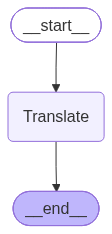

In [8]:
subGraph

In [10]:
subGraph.invoke(input={
    'english_text':'my name is rajendra prasad joshi.'
})

{'english_text': 'my name is rajendra prasad joshi.',
 'nepali_text': 'मेरो नाम राजेन्द्र प्रसाद जोशी हो।'}

### now create a Graph and call the subGraph inside a node

In [11]:
class graphState(TypedDict):
    question : str
    answer : str
    translated_answer : str

In [12]:
def Generate(state:graphState):
    response = llm.invoke(state['question']).content
    return {'answer':response}

In [13]:

def Translate_answer(state:graphState):
    english_text = state['answer']
    response = subGraph.invoke(input ={
        'english_text':english_text
    })
    nepali_text = response['nepali_text']

    return {'translated_answer':nepali_text}

In [14]:
graphBuilder = StateGraph(state_schema=graphState)

graphBuilder.add_node('Generate',Generate)
graphBuilder.add_node('Translate_answer',Translate_answer)

graphBuilder.add_edge(START,'Generate')
graphBuilder.add_edge('Generate','Translate_answer')

graph = graphBuilder.compile()

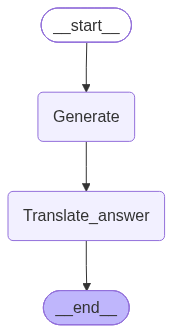

In [15]:

graph

In [16]:
graph.invoke(input={
    'question':'tell me all thing you know about sudurpaschim nepal?'
})

{'question': 'tell me all thing you know about sudurpaschim nepal?',
 'answer': 'Sudurpaschim Pradesh, also known as Far Western Province, is one of the seven provinces of Nepal. Here are some key points about Sudurpaschim:\n\n### Geography\n- **Location**: Situated in the far western part of Nepal, Sudurpaschim is bordered by the Darchula District to the west, the Mahakali River to the north (which forms part of the border with India), and by India to the south.\n- **Topography**: The province has diverse landscapes, including the lowland Terai plains in the south and the mountainous region in the north, which includes parts of the Himalayan range.\n\n### Administrative Structure\n- **Capital**: The provincial capital is Dhangadhi, which is a significant urban and economic center.\n- **Districts**: Sudurpaschim Pradesh consists of nine districts: Darchula, Dadeldhura, Bajhang, Bajura, Achham, Doti, Kailali, Kanchanpur, and Syangja.\n\n### Economy\n- **Agriculture**: The economy of Sud